In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
x = np.array([1, 3, 4, 6, 7])
y = np.array([15, 30, 35, 40, 45])

<Axes: >

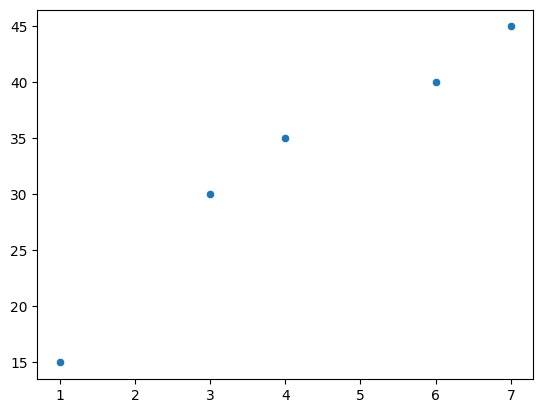

In [5]:
sns.scatterplot(x=x, y=y)

In [9]:
def make_prediction(x, y, w, b):
    m = x.shape[0]
    
    pred_list = np.zeros((m,))
    
    for i in range(m):
        pred_list[i] = w * x[i] + b
        
    return pred_list

[11. 13. 14. 16. 17.]


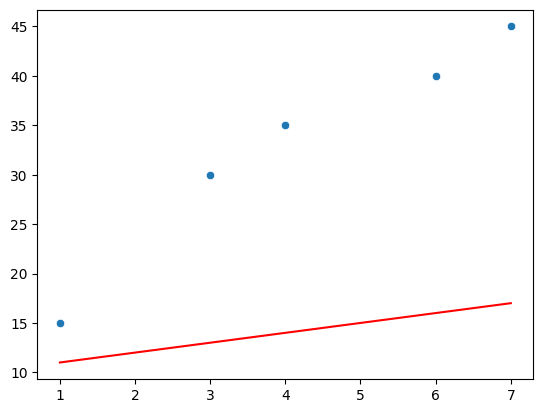

In [12]:
predictions = make_prediction(x, y, w= 1, b= 10)
print(predictions)
sns.scatterplot(x=x, y=y)
plt.plot(x,predictions, color='red')

In [14]:
def compute_cost(x, y, w, b):
    m = x.shape[0] #number of data points
    
    cost = 0.0
    
    for i in range(m):
        prediction = w * x[i] + b
        error = prediction - y[i]
        error_squared = error ** 2
        cost += error_squared
        
    cost = cost/m
        
    return cost

[0. 0. 0. 0. 0.]


Text(0.5, 1.0, 'Cost: 1195.0,for w = 0.0 and b = 0.0')

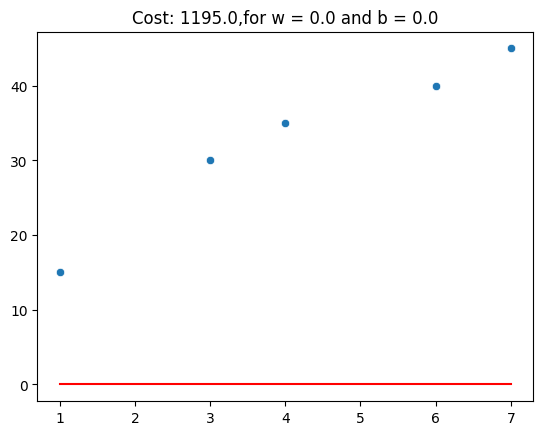

In [15]:
w = 0.0
b = 0.0

predictions = make_prediction(x, y, w= w, b= b)
print(predictions)

sns.scatterplot(x=x, y=y)
plt.plot(x,predictions, color='red')

plt.title(f"Cost: {compute_cost(x, y, w= 0, b= 0)},for w = {w} and b = {b}")

[1. 3. 4. 6. 7.]


Text(0.5, 1.0, 'Cost: 1195.0,for w = 1.0 and b = 0.0')

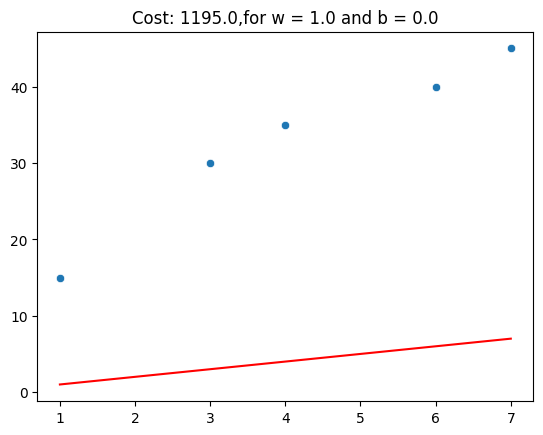

In [16]:
w = 1.0
b = 0.0

predictions = make_prediction(x, y, w= w, b= b)
print(predictions)

sns.scatterplot(x=x, y=y)
plt.plot(x,predictions, color='red')

plt.title(f"Cost: {compute_cost(x, y, w= 0, b= 0)},for w = {w} and b = {b}")

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost: 1195.0,for w = 10.0 and b = 5.0')

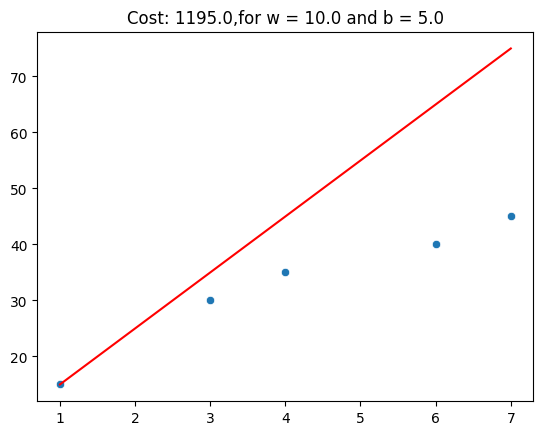

In [18]:
w = 10.0
b = 5.0

predictions = make_prediction(x, y, w= w, b= b)
print(predictions)

sns.scatterplot(x=x, y=y)
plt.plot(x,predictions, color='red')

plt.title(f"Cost: {compute_cost(x, y, w= 0, b= 0)},for w = {w} and b = {b}")

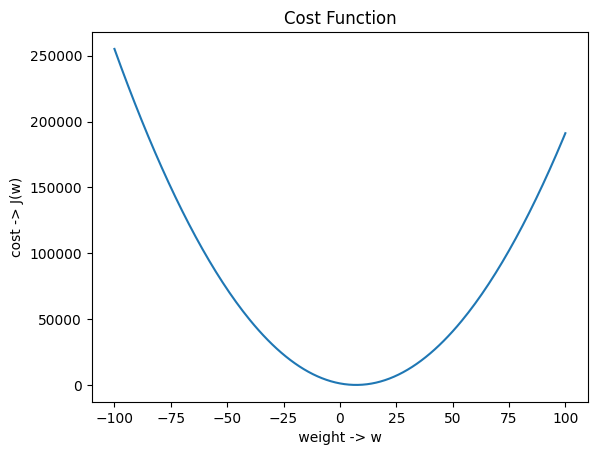

In [21]:
w = []
cost = []

# w-> -100 to 101
for i in range(-100, 101):
    cost_i = compute_cost(x, y, w= i, b= 0)
    w.append(i)
    cost.append(cost_i)
    
plt.plot(w, cost)
plt.xlabel(" weight -> w ")
plt.ylabel("cost -> J(w)")
plt.title("Cost Function")
plt.show()

In [22]:
def calculate_gradient(x, y, w, b):
    m = x.shape[0]
    
    dj_dw = 0.0
    dj_db = 0.0
    
    for i in range(m):
        prediction = w * x[i] + b
        error = prediction - y[i]
        
        dj_dw += error * x[i]
        dj_db += error
        
    dj_dw = dj_dw/m
    dj_db = dj_db/m
    
    return dj_dw, dj_db

In [23]:
calculate_gradient(x, y, w= 0, b= 0)

(np.float64(-160.0), np.float64(-33.0))

In [31]:
def gradient_descent(x, y, w_in, b_in, max_iteration, alpha=0.01):
    w = w_in
    b = b_in
    
    cost_memo = []
    iteration = []
    
    for i in range(max_iteration):
        dj_dw, dj_db = calculate_gradient(x, y, w, b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost = compute_cost(x, y, w, b)
        cost_memo.append(cost)
        iteration.append(i)
        
        if i%100 == 0:
            print(f"Iteration {i}: Cost {cost_memo[-1]}, w: {w}, b: {b}")
        
        
    return w, b ,cost_memo, iteration

In [32]:
w,b,memo,iteration = gradient_descent(x, y, w_in= 0, b_in= 0, max_iteration= 1000, alpha= 0.01)

Iteration 0: Cost 722.5961, w: 1.6, b: 0.33
Iteration 100: Cost 25.247529087942223, w: 6.561087114811478, b: 3.5033832995060097
Iteration 200: Cost 18.801450917525234, w: 6.224841178652057, b: 5.264811979462869
Iteration 300: Cost 14.467034941099872, w: 5.949117188642135, b: 6.709195662629804
Iteration 400: Cost 11.552524542682505, w: 5.723021612499477, b: 7.893600258707672
Iteration 500: Cost 9.592774738168293, w: 5.537621678495041, b: 8.864820207782826
Iteration 600: Cost 8.275016771554405, w: 5.3855924521153, b: 9.66122727391982
Iteration 700: Cost 7.38894138857722, w: 5.260927436468266, b: 10.314286568672692
Iteration 800: Cost 6.7931342644999315, w: 5.158701262617614, b: 10.84979970083487
Iteration 900: Cost 6.392506805571412, w: 5.074875094017663, b: 11.288924167820179


5.006759105675131 11.645750652600126
[16.65250976 26.66602797 31.67278708 41.68630529 46.69306439]


Text(0.5, 1.0, 'Cost: 1195.0,for w = 5.006759105675131 and b = 11.645750652600126')

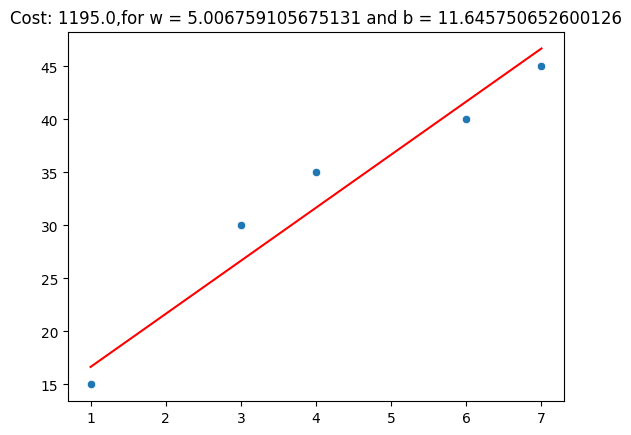

In [34]:
print(w,b)

predictions = make_prediction(x, y, w= w, b= b)
print(predictions)

sns.scatterplot(x=x, y=y)
plt.plot(x,predictions, color='red')

plt.title(f"Cost: {compute_cost(x, y, w= 0, b= 0)},for w = {w} and b = {b}")

Text(0, 0.5, 'Cost')

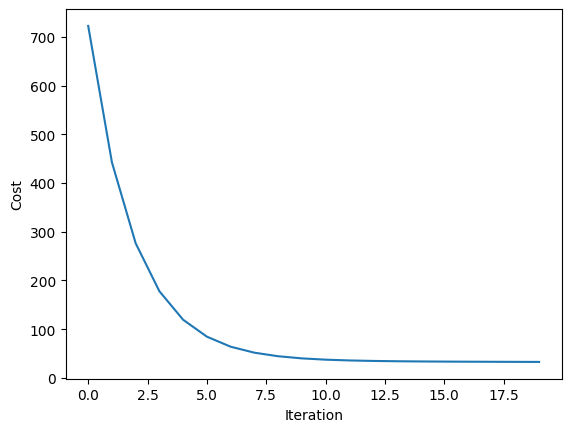

In [39]:
plt.plot(iteration[:20], memo[:20])
plt.xlabel("Iteration")
plt.ylabel("Cost")